In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.head())
print(df.info())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

In [3]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2,random_state=42)

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [7]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²:", lr_r2)

Linear Regression RMSE: 0.7455813830127763
Linear Regression R²: 0.575787706032451


In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

In [9]:
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge RMSE: 0.7455542909384607
Ridge R²: 0.5758185345441323


In [10]:
tree = DecisionTreeRegressor( max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

In [11]:
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R²:", tree_r2)

Decision Tree RMSE: 0.7242338143386247
Decision Tree R²: 0.5997321244428706


In [12]:
results = pd.DataFrame({ "Model": ["Linear Regression","Ridge Regression","Decision Tree"],"RMSE": [ lr_rmse, ridge_rmse, tree_rmse], "R2 Score": [lr_r2,ridge_r2, tree_r2 ]})
print(results)

               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745554  0.575819
2      Decision Tree  0.724234  0.599732


In [13]:
best_model = results.sort_values( by="R2 Score", ascending=False)
print(best_model)

               Model      RMSE  R2 Score
2      Decision Tree  0.724234  0.599732
1   Ridge Regression  0.745554  0.575819
0  Linear Regression  0.745581  0.575788


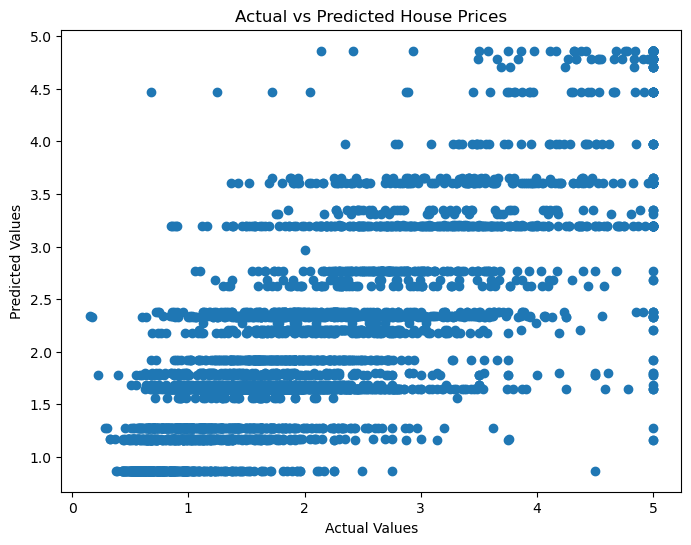

<Figure size 640x480 with 0 Axes>

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, tree_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()
plt.savefig("ActualvsPredictedPrices.png")

In [15]:
import pandas as pd
results = pd.DataFrame({"Model": [ "Linear Regression","Ridge Regression","Decision Tree Regressor" ],"RMSE": [ lr_rmse, ridge_rmse, tree_rmse],"R2 Score": [lr_r2,ridge_r2,tree_r2 ]})
print(results)

                     Model      RMSE  R2 Score
0        Linear Regression  0.745581  0.575788
1         Ridge Regression  0.745554  0.575819
2  Decision Tree Regressor  0.724234  0.599732


In [16]:
best_model = results.loc[results["R2 Score"].idxmax()]
print(best_model)

Model       Decision Tree Regressor
RMSE                       0.724234
R2 Score                   0.599732
Name: 2, dtype: object


In [17]:
import os
print(os.getcwd())

C:\Users\saanv\anaconda_projects\667f3744-a517-45ba-97bf-f7ec87121a19


In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [19]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [20]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

In [21]:
r2 = r2_score(y_test, predictions)

In [22]:
print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.7030445773467542
R2 Score: 0.6228111330554302


In [23]:
scores = cross_val_score( model,X, y, cv=5,scoring='r2')
print(scores)

[0.27093461 0.41372445 0.43912441 0.23566991 0.41875969]


In [24]:
print("Average R2:", scores.mean())

Average R2: 0.355642615410327


In [25]:
train_score = model.score(X_train, y_train)

In [26]:
test_score = model.score(X_test, y_test)

In [27]:
print(train_score)
print(test_score)

1.0
0.6228111330554302


In [28]:
parameters = { 'max_depth':[3,5,7,10,None],'min_samples_split':[2,5,10],'min_samples_leaf':[1,2,4]}

In [29]:
grid = GridSearchCV( estimator=DecisionTreeRegressor(random_state=42), param_grid=parameters,cv=5,scoring='r2')

In [30]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [31]:
print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [32]:
{'max_depth':7,'min_samples_leaf':2,'min_samples_split':5}

{'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}

In [33]:
best_model = grid.best_estimator_

In [34]:
new_predictions = best_model.predict(X_test)

In [35]:
new_rmse = np.sqrt(mean_squared_error(y_test,new_predictions))

In [36]:
new_r2 = r2_score(y_test,new_predictions)

print(new_rmse)
print(new_r2)

In [37]:
# Model Comparison

| Metric | Before Tuning | After Tuning |
|---------|---------------|--------------|
| RMSE | | |
| R² Score | | |

# Model Comparison

| Metric | Baseline Decision Tree | Tuned Decision Tree |
|--------|------------------------:|--------------------:|
| RMSE | 0.7030 | 0.6389 |
| R² Score | 0.6228 | 0.6885 |

# Observations

- The RMSE decreased from **0.7030** to **0.6389**, indicating that the prediction error was reduced.
- The R² score increased from **0.6228** to **0.6885**, showing that the tuned model explains more variance in the data.
- GridSearchCV successfully identified better hyperparameters for the Decision Tree Regressor.
- The tuned model performs better than the baseline model and is selected as the final model.

# Cross Validation

Cross-validation is a model validation technique used to evaluate the performance of a machine learning model on different subsets of the dataset. In this project, 5-fold cross-validation was performed, where the dataset was divided into five equal parts. The model was trained on four folds and tested on the remaining fold, repeating the process five times. The average R² score obtained was **0.3556**, providing a more reliable estimate of model performance than a single train-test split.

# Overfitting Analysis

The baseline Decision Tree Regressor achieved a training score of **1.0000** but a testing score of **0.6228**. This significant difference indicates that the model memorized the training data instead of learning general patterns, resulting in overfitting. Hyperparameter tuning reduced the complexity of the model and improved its ability to generalize to unseen data.

# Hyperparameter Tuning

GridSearchCV was used to search for the best combination of hyperparameters for the Decision Tree Regressor. The parameters tested included max_depth, min_samples_split, and min_samples_leaf. Using 5-fold cross-validation, the best combination was found to be:

- max_depth = 10
- min_samples_leaf = 4
- min_samples_split = 2

These parameters produced a model with better prediction accuracy and improved generalization.

# Conclusion

In this task, a Decision Tree Regressor was trained and evaluated for house price prediction. The model was validated using RMSE and R² score, and 5-fold cross-validation was applied to obtain a reliable estimate of its performance. Hyperparameter tuning using GridSearchCV improved the model by selecting the optimal parameter values. The RMSE decreased from **0.7030** to **0.6389**, while the R² score increased from **0.6228** to **0.6885**. These results show that the tuned model performs better than the baseline model and is more suitable for predicting house prices.